In [1]:
from pathlib import Path
import anndata
import numpy as np
import scanpy as sc
import scvi
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from cytetype import CyteType

/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.4.2


In [3]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
model_dir = Path.cwd().parent / "models"

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Load processed data

In [ ]:
# Load data
adata = sc.read(
    filename=Path.cwd().parent / "data" / "breastcancer_scatlas_filter.h5ad",
    # backup_url=(
    #     "https://datasets.cellxgene.cziscience.com/7cdea341-ca7a-40fd-8192-b8ecb2d7b91e.h5ad"
    # ),
)
adata

AnnData object with n_obs × n_vars = 621200 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

In [6]:
# Filter cells with few genes
sc.pp.filter_cells(adata, min_genes=500)

# Filter genes that appear in few cells
sc.pp.filter_genes(adata, min_cells=60)

In [7]:
# Save raw counts to `counts` layer in anndata object
adata.layers["counts"] = adata.X.astype(np.int32)

# Normalize cells to 10,000 counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Change to log scale
sc.pp.log1p(adata)

# Save raw data
adata.raw = adata

In [8]:
# Perform feature selection
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1500,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="batch",
)

In [9]:
# Setup anndata object for model fitting
scvi.model.SCVI.setup_anndata(
    adata, layer="counts", categorical_covariate_keys=["donor_id", "assay"]
)

# Load scVI model

In [11]:
# Load model
model = scvi.model.SCVI.load(Path.cwd().parent / "models" / "scvi1", adata=adata)

INFO     File /Users/otodreas/Desktop/Work/Nygen/Interview/models/scvi1/model.pt already downloaded                


/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/scvi/model/base/_base_model.py:899: UserWarning: `var_names` for the loaded `model` does not match those used to train the model. For valid results, the former should match the latter.
  _validate_var_names(adata, var_names)


# Plot model training diagnostics

In [12]:
# Assign model history to variable
hist = model.history


# Set matplotlib aesthetics
def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

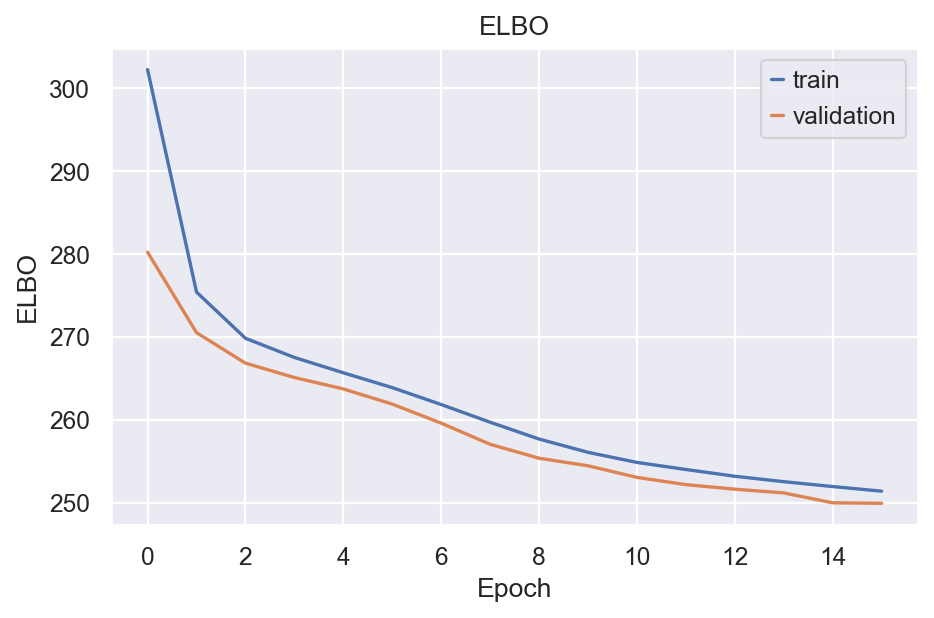

In [13]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

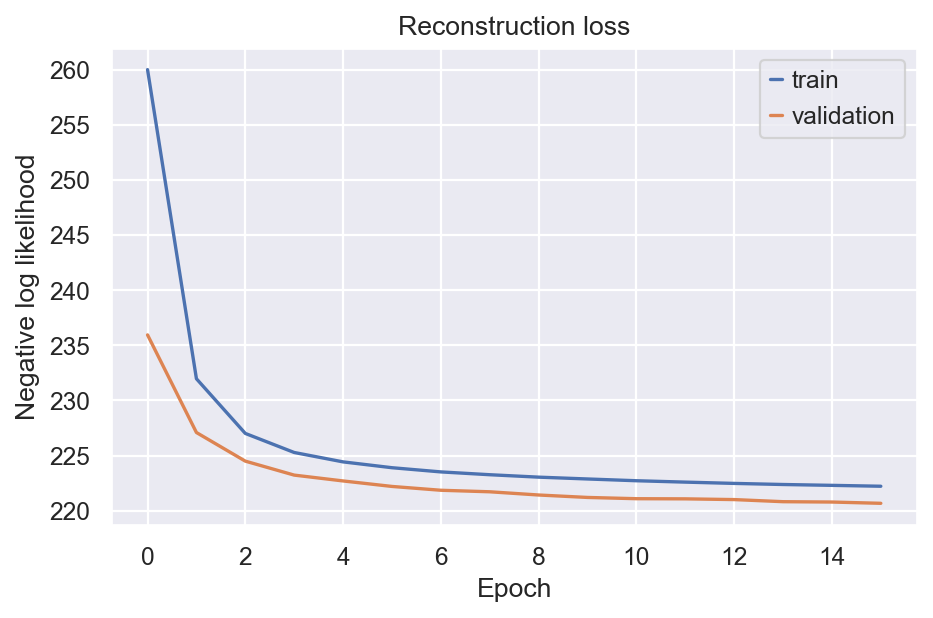

In [14]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

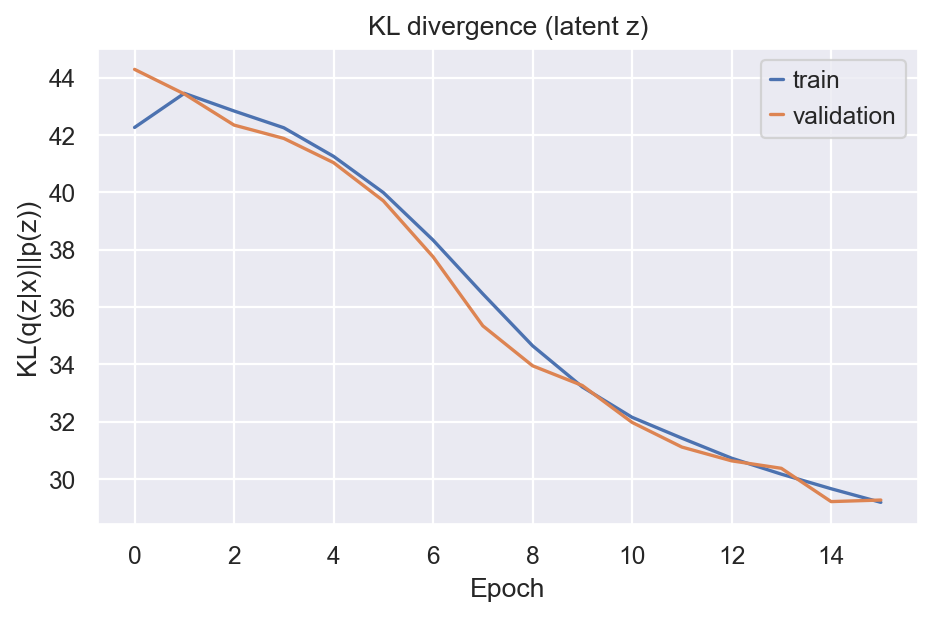

In [15]:
# Local KL divergence
plot_metric(
    "kl_local_train",
    "kl_local_validation",
    "KL divergence (latent z)",
    "KL(q(z|x)||p(z))",
)

# Cluster

In [16]:
# run PCA then generate UMAP plots
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

SystemError: CPUDispatcher(<function nn_descent at 0x13cd6ab60>) returned a result with an exception set

In [ ]:
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
)

# Run CyteType

In [ ]:
group_key = "clusters"
annotator = CyteType(
    adata, group_key=group_key, rank_key="rank_genes_" + group_key, n_top_genes=100
)
adata = annotator.run(study_context="Human PBMC from healthy donor")
sc.pl.umap(adata, color="cytetype_annotation_clusters")